# Máquinas de soporte vectorial (SVM)

> Cómo separar dos clases con el hiperplano de **margen máximo**, cómo tolerar errores con el parámetro $C$ y cómo conseguir fronteras curvas con funciones **núcleo** (*kernel*) sin salir del marco lineal. Incluye el papel de $\gamma$, el escalado, el coste y los límites del método.
>
> **Requisitos previos:** [Flujo de ML y evaluación](01-flujo-ml-y-evaluacion.ipynb) · [distancias y escalado](../03-preparacion-datos/05-distancias-y-similitud.ipynb) · **Relacionado:** [k-NN](07-knn.ipynb) · [árboles de decisión](08-arboles-decision.ipynb)

## 1. Idea clave

Una **máquina de soporte vectorial** (*support vector machine*, SVM) clasifica buscando, entre todos los hiperplanos que separan las clases, el que deja el **mayor margen** (la mayor "calle vacía") a ambos lados. Solo unos pocos puntos, los **vectores de soporte** (los que tocan el margen o lo violan), determinan el hiperplano; el resto de los datos podría borrarse sin cambiar el modelo.

Con dos ideas se vuelve muy versátil: el **margen blando** (parámetro $C$) permite que algunos puntos queden dentro del margen o mal clasificados cuando las clases se solapan, y el **truco del núcleo** (*kernel trick*) obtiene fronteras curvas calculando productos escalares en un espacio de más dimensiones sin construirlo.

Funciona bien con tamaños **pequeños y medianos**, con muchas variables y fronteras complejas. Exige **escalar** los datos, su coste crece rápido con el número de filas y es poco interpretable (salvo con núcleo lineal). Con cientos de miles de filas, mejor un modelo lineal o un [bosque](10-bagging-y-random-forest.ipynb).

## 2. Conceptos importantes

### 2.1. Hiperplano y margen

Con clases codificadas como $y_i \in \{-1, +1\}$, un hiperplano es el conjunto de puntos donde $f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b = 0$, y el vector $\mathbf{w}$ es perpendicular a él. La **distancia** de un punto $\mathbf{x}$ al hiperplano es $|f(\mathbf{x})| / \lVert \mathbf{w} \rVert$. Si imponemos que los puntos más próximos cumplan $|f(\mathbf{x})| = 1$, el **margen** (la anchura de la calle) vale

$$
\text{margen} = \frac{2}{\lVert \mathbf{w} \rVert}
$$

Maximizar el margen equivale a minimizar $\lVert \mathbf{w} \rVert$. Si las clases son separables (*hard margin*), el problema es

$$
\min_{\mathbf{w},\, b}\ \tfrac{1}{2} \lVert \mathbf{w} \rVert^2 \quad \text{sujeto a} \quad y_i\,(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 \ \ \text{para todo } i
$$

### 2.2. Margen blando y el parámetro $C$

Con datos reales las clases se solapan y esa condición es imposible. El **margen blando** (*soft margin*) introduce una holgura $\xi_i \ge 0$ por punto (cuánto viola el margen) y la penaliza:

$$
\min_{\mathbf{w},\, b,\, \xi}\ \tfrac{1}{2} \lVert \mathbf{w} \rVert^2 + C \sum_i \xi_i \quad \text{sujeto a} \quad y_i\,(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 - \xi_i,\ \ \xi_i \ge 0
$$

$C$ fija el compromiso entre margen ancho y errores:

- **$C$ pequeño**: se toleran muchas violaciones, el margen es ancho y el modelo más simple (más regularización, riesgo de subajuste).
- **$C$ grande**: cada violación cuesta mucho, el margen se estrecha para clasificar bien el entrenamiento (menos regularización, riesgo de sobreajuste).

Los **vectores de soporte** son los puntos sobre el margen, dentro de él o mal clasificados ($\alpha_i > 0$ en la forma dual); los demás no influyen.

### 2.3. El truco del núcleo

En la forma dual, el modelo solo usa **productos escalares** entre puntos:

$$
f(\mathbf{x}) = \sum_{i \in \text{SV}} \alpha_i\, y_i\, k(\mathbf{x}_i, \mathbf{x}) + b
$$

donde la suma recorre los vectores de soporte, $\alpha_i$ son sus pesos y $k(\mathbf{a}, \mathbf{b}) = \langle \varphi(\mathbf{a}), \varphi(\mathbf{b}) \rangle$ es una **función núcleo**: el producto escalar de los puntos tras llevarlos a otro espacio mediante una transformación $\varphi$. Lo importante es que se puede calcular $k$ **sin construir** $\varphi$. Un ejemplo: unos círculos concéntricos no se separan con una recta, pero tras la transformación $(u_1, u_2) \mapsto (u_1, u_2, u_1^2 + u_2^2)$ (añadir el radio al cuadrado) sí se separan con un plano.

Los núcleos habituales (con $\gamma > 0$):

| Núcleo | $k(\mathbf{a}, \mathbf{b})$ | Comentario |
|---|---|---|
| Lineal | $\mathbf{a}^\top \mathbf{b}$ | Sin transformación; frontera lineal |
| Polinómico | $(\gamma\, \mathbf{a}^\top \mathbf{b} + r)^d$ | Interacciones hasta grado $d$ |
| **Radial (RBF)** | $\exp(-\gamma \lVert \mathbf{a} - \mathbf{b} \rVert^2)$ | El más usado; fronteras flexibles |
| Sigmoide | $\tanh(\gamma\, \mathbf{a}^\top \mathbf{b} + r)$ | Con algunos parámetros no es un núcleo válido |

En el núcleo radial, $k$ mide **similitud**: vale 1 si los puntos coinciden y cae hacia 0 al alejarse. $\gamma$ controla con qué rapidez: con $\gamma$ **pequeño** cada punto influye en una zona amplia (frontera suave, riesgo de subajuste); con $\gamma$ **grande**, solo en su entorno inmediato (frontera muy local, riesgo de sobreajuste, con una "isla" alrededor de cada punto).

### 2.4. Multiclase, regresión y probabilidades

- **Multiclase**: `SVC` entrena un clasificador por cada par de clases (*one-vs-one*) y vota.
- **Regresión (SVR)**: ajusta una función dejando un "tubo" de anchura $\varepsilon$ en el que los errores no se penalizan; solo los puntos fuera del tubo son vectores de soporte.
- **Puntuación y probabilidad**: `decision_function` da la distancia con signo al hiperplano. Para obtener probabilidades hay que calibrar esa puntuación (regresión logística de Platt) con una validación cruzada adicional, con `CalibratedClassifierCV`; es costoso, y las probabilidades calibradas pueden no coincidir con las clases de `predict`.

### 2.5. Escalado y coste

El núcleo radial depende de **distancias euclídeas**, y el margen, de la escala de las variables: hay que [estandarizar](../03-preparacion-datos/03-transformacion-datos.ipynb). El entrenamiento resuelve un problema cuadrático cuyo coste crece entre $O(n^2)$ y $O(n^3)$ con el número de filas $n$.

## 3. Código

Usamos datos sintéticos (`make_blobs`, `make_circles`, `make_moons`) para ver geometría y núcleos, y dos conjuntos reales de scikit-learn: **dígitos escritos a mano** (`load_digits`: 1.797 imágenes de 8×8 píxeles, 10 clases) para ajustar $C$ y $\gamma$, y **breast cancer** (569 tumores, 30 medidas) para el efecto del escalado. Ambos derivan de datasets del repositorio UCI.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.datasets import load_breast_cancer, load_digits, make_blobs, make_circles, make_classification, make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR, LinearSVC


def dibujar_svm(modelo, X, y, eje, titulo):
    # Regiones de decisión, margen (curvas de nivel -1, 0, 1) y vectores de soporte rodeados
    DecisionBoundaryDisplay.from_estimator(modelo, X, response_method="decision_function", levels=[-1, 0, 1],
                                           colors="k", linestyles=["--", "-", "--"], plot_method="contour", ax=eje)
    DecisionBoundaryDisplay.from_estimator(modelo, X, response_method="predict", cmap="coolwarm", alpha=0.2, ax=eje)
    eje.scatter(*X.T, c=y, cmap="coolwarm", s=15, edgecolor="k", linewidth=0.3)
    eje.scatter(*modelo.support_vectors_.T, s=80, facecolors="none", edgecolors="k")
    eje.set_title(titulo)
    eje.set_xlabel("Atributo 1")

### 3.1. Margen y vectores de soporte, según $C$

Dos grupos que se solapan algo y un SVM lineal. Para cada $C$ dibujamos el hiperplano (línea continua), el margen (discontinuas) y los vectores de soporte (rodeados), y medimos la anchura del margen $2 / \lVert \mathbf{w} \rVert$.

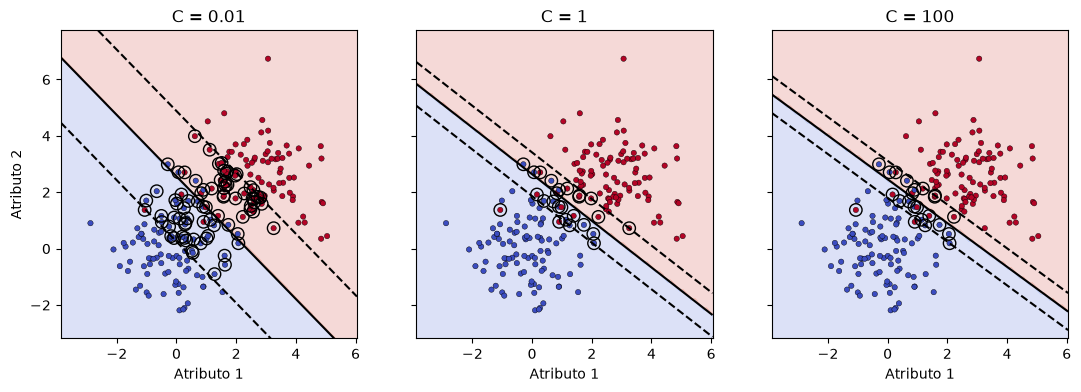

,anchura del margen,vectores de soporte,exactitud entrenamiento
C = 0.01,3.13,78,0.95
C = 1,1.19,25,0.96
C = 100,1.04,23,0.96


In [2]:
X_blobs, y_blobs = make_blobs(n_samples=200, centers=[[0, 0], [2.5, 2.5]], cluster_std=1.1, random_state=42)

fig, ejes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
filas = {}
for eje, C in zip(ejes, [0.01, 1, 100]):
    svm = SVC(kernel="linear", C=C).fit(X_blobs, y_blobs)
    dibujar_svm(svm, X_blobs, y_blobs, eje, f"C = {C}")
    filas[f"C = {C}"] = {"anchura del margen": 2 / np.linalg.norm(svm.coef_[0]),
                         "vectores de soporte": svm.n_support_.sum(),
                         "exactitud entrenamiento": svm.score(X_blobs, y_blobs)}
ejes[0].set_ylabel("Atributo 2")
plt.show()
pd.DataFrame.from_dict(filas, orient="index").round(2)

Con $C$ pequeño el margen es ancho (3,13) y casi el 40 % de los puntos (78 de 200) son vectores de soporte: el modelo tolera muchas violaciones. Al subir $C$, el margen se estrecha (1,04 con $C = 100$) y quedan solo 23 vectores de soporte, los que de verdad sostienen la frontera. El resto de los puntos se podría eliminar sin cambiar el modelo.

### 3.2. Fronteras curvas con núcleos

Dos círculos concéntricos (`make_circles`) no se separan con una recta. Comparamos el núcleo lineal, el polinómico de grado 2 y el radial, y también la transformación explícita de la sección 2.3 (añadir $u_1^2 + u_2^2$) con un SVM lineal.

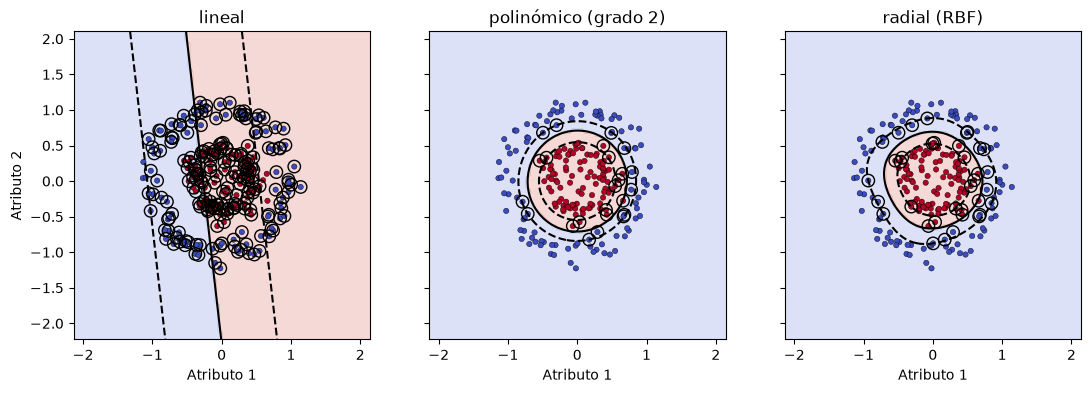

,exactitud test,vectores de soporte
lineal,0.533,204.0
polinómico (grado 2),1.000,24.0
radial (RBF),1.000,36.0
lineal + radio²,1.000,NaN


In [3]:
X_circ, y_circ = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_circ, y_circ, test_size=0.3, stratify=y_circ, random_state=42)

modelos = {"lineal": SVC(kernel="linear"), "polinómico (grado 2)": SVC(kernel="poly", degree=2), "radial (RBF)": SVC(kernel="rbf")}
fig, ejes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
filas = {}
for eje, (nombre, modelo) in zip(ejes, modelos.items()):
    modelo.fit(Xc_train, yc_train)
    dibujar_svm(modelo, Xc_train, yc_train, eje, nombre)
    filas[nombre] = {"exactitud test": modelo.score(Xc_test, yc_test), "vectores de soporte": modelo.n_support_.sum()}
ejes[0].set_ylabel("Atributo 2")
plt.show()

# El mismo efecto "a mano": añadir el radio al cuadrado y usar un SVM lineal
con_radio = lambda X: np.c_[X, (X ** 2).sum(axis=1)]
lineal_3d = LinearSVC(max_iter=10000).fit(con_radio(Xc_train), yc_train)
filas["lineal + radio²"] = {"exactitud test": lineal_3d.score(con_radio(Xc_test), yc_test), "vectores de soporte": np.nan}
pd.DataFrame.from_dict(filas, orient="index").round(3)

El núcleo lineal se queda en azar (≈ 0,5): ninguna recta separa los anillos. Los núcleos polinómico y radial lo resuelven (≈ 1,0), con muy pocos vectores de soporte. Y la transformación explícita (añadir el radio al cuadrado) consigue lo mismo con un SVM **lineal** en 3D: eso es el truco del núcleo, con la diferencia de que el núcleo lo hace sin llegar a calcular la dimensión extra.

### 3.3. El parámetro $\gamma$ del núcleo radial

Lunas con mucho ruido, $C = 1$ y cuatro valores de $\gamma$. Medimos entrenamiento, test y validación cruzada (la más fiable con tan pocos datos).

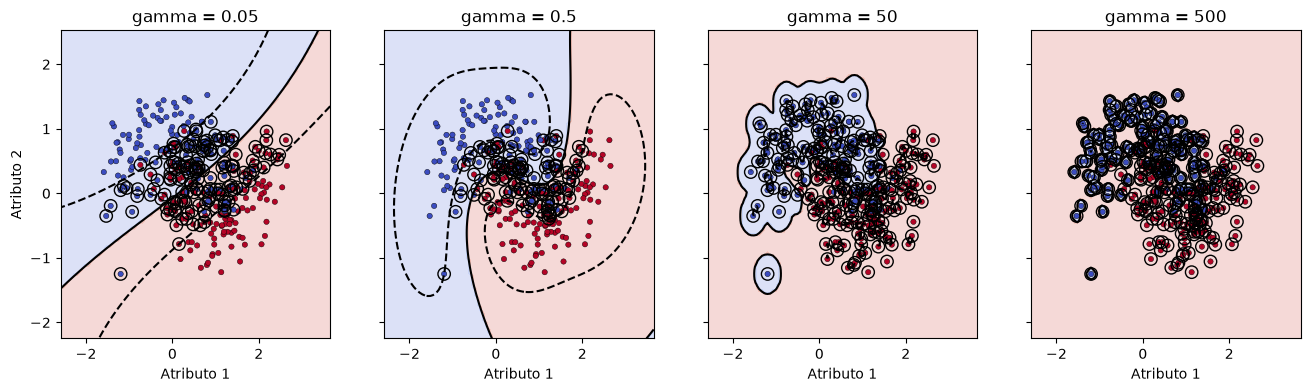

,entrenamiento,test,CV media,vectores de soporte
gamma = 0.05,0.800,0.883,0.804,155
gamma = 0.5,0.857,0.917,0.854,119
gamma = 50,0.918,0.858,0.786,242
gamma = 500,0.996,0.592,0.636,279


In [4]:
X_lunas, y_lunas = make_moons(n_samples=400, noise=0.35, random_state=42)
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_lunas, y_lunas, test_size=0.3, stratify=y_lunas, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, ejes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
filas = {}
for eje, gamma in zip(ejes, [0.05, 0.5, 50, 500]):
    svm = SVC(kernel="rbf", gamma=gamma, C=1).fit(Xl_train, yl_train)
    dibujar_svm(svm, Xl_train, yl_train, eje, f"gamma = {gamma}")
    filas[f"gamma = {gamma}"] = {"entrenamiento": svm.score(Xl_train, yl_train), "test": svm.score(Xl_test, yl_test),
                                 "CV media": cross_val_score(SVC(kernel="rbf", gamma=gamma, C=1), Xl_train, yl_train, cv=cv).mean(),
                                 "vectores de soporte": svm.n_support_.sum()}
ejes[0].set_ylabel("Atributo 2")
plt.show()
pd.DataFrame.from_dict(filas, orient="index").round(3)

Con $\gamma = 0{,}05$ la frontera es casi recta y el modelo se queda corto (CV ≈ 0,80). Entre 0,5 y 50 hay una zona razonable (CV ≈ 0,79–0,85), y con $\gamma = 500$ el modelo **memoriza**: 99,6 % en entrenamiento, pero solo ≈ 0,59 en test y 0,64 en validación cruzada. Con $\gamma = 50$ la región azul ya es una mancha irregular, y con $\gamma = 500$ el fondo es rojo en todas partes salvo en torno a los puntos azules: casi todos los puntos (279 de 280) son vectores de soporte. Las diferencias en test entre valores intermedios son ruido (con 120 casos): decide con la validación cruzada.

### 3.4. Datos reales: dígitos y búsqueda de $C$ y $\gamma$

$C$ y $\gamma$ interactúan, así que se buscan **juntos** con una rejilla en escala logarítmica (los efectos son multiplicativos). Los píxeles ya comparten escala (0 a 16), por lo que no hace falta estandarizar.

Mejores parámetros: {'C': 1, 'gamma': 0.001} | CV = 0.991 | test = 0.989


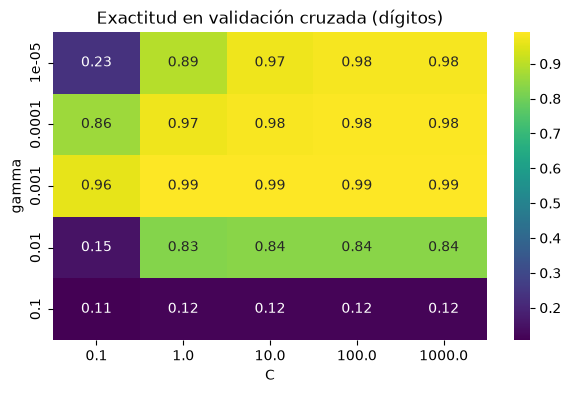

SVC con valores por defecto: test = 0.991 | gamma='scale' = 0.00043 | vectores de soporte: 631 de 1347


In [5]:
X_dig, y_dig = load_digits(return_X_y=True)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X_dig, y_dig, test_size=0.25, stratify=y_dig, random_state=42)

rejilla = {"C": [0.1, 1, 10, 100, 1000], "gamma": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]}
busqueda = GridSearchCV(SVC(kernel="rbf"), rejilla, cv=cv).fit(Xd_train, yd_train)
print("Mejores parámetros:", busqueda.best_params_, f"| CV = {busqueda.best_score_:.3f} | test = {busqueda.score(Xd_test, yd_test):.3f}")

resultados = pd.DataFrame(busqueda.cv_results_).pivot(index="param_gamma", columns="param_C", values="mean_test_score")
plt.figure(figsize=(7, 4))
sns.heatmap(resultados.astype(float), annot=True, fmt=".2f", cmap="viridis")
plt.title("Exactitud en validación cruzada (dígitos)")
plt.xlabel("C")
plt.ylabel("gamma")
plt.show()

por_defecto = SVC().fit(Xd_train, yd_train)
print(f"SVC con valores por defecto: test = {por_defecto.score(Xd_test, yd_test):.3f} | "
      f"gamma='scale' = {1 / (X_dig.shape[1] * Xd_train.var()):.5f} | vectores de soporte: {por_defecto.n_support_.sum()} de {len(Xd_train)}")

El mejor punto de la rejilla ($C = 1$, $\gamma = 10^{-3}$) queda **en el interior**, no en un borde, y da ≈ 0,99 en validación cruzada y en test. Fíjate en el patrón de la rejilla:

- Con $\gamma \ge 10^{-2}$ el rendimiento cae (≈ 0,83 con $\gamma = 10^{-2}$ y ≈ 0,12 con $\gamma = 0{,}1$, apenas por encima del azar, 0,10): cada punto solo influye sobre sí mismo, y el modelo memoriza.
- Con $\gamma$ muy pequeña ($10^{-5}$), hace falta un $C$ enorme para compensar.
- Una vez en la zona buena de $\gamma$, $C$ apenas importa (de 1 a 1000 casi no cambia).

El valor por defecto `gamma="scale"` (≈ 0,0004) ya queda en la zona buena, y el `SVC` sin ajustar rinde igual (0,991 frente a 0,989): es un excelente punto de partida. Casi la mitad del entrenamiento (631 de 1.347) son vectores de soporte.

### 3.5. El escalado es imprescindible

En breast cancer, las variables tienen escalas de órdenes de magnitud distintos (el área frente a la suavidad). Comparamos un `SVC` sin escalar y con un `Pipeline` que estandariza primero:

In [6]:
X_bc, y_bc = load_breast_cancer(return_X_y=True)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42)

modelos = {"sin escalar": SVC(), "estandarizado": make_pipeline(StandardScaler(), SVC())}
pd.DataFrame.from_dict({
    nombre: {"exactitud CV": cross_val_score(modelo, Xb_train, yb_train, cv=cv).mean(),
             "exactitud test": modelo.fit(Xb_train, yb_train).score(Xb_test, yb_test)}
    for nombre, modelo in modelos.items()
}, orient="index").round(3)

,exactitud CV,exactitud test
sin escalar,0.905,0.930
estandarizado,0.969,0.982


Estandarizar sube la exactitud en validación cruzada de ≈ 0,91 a ≈ 0,97, y en test, de 0,93 a 0,98. Sin escalar, las variables con valores grandes dominan la distancia del núcleo.

### 3.6. Coste con el número de filas

Medimos el tiempo de entrenamiento de `SVC` (núcleo radial) y de `LinearSVC` al duplicar los datos (los tiempos dependen de la máquina; importa cómo crecen):

In [7]:
filas = {}
for n in [2000, 4000, 8000, 16000]:
    X_g, y_g = make_classification(n_samples=n, n_features=20, n_informative=10, random_state=0)
    tiempos = {}
    for nombre, modelo in [("SVC (RBF)", SVC()), ("LinearSVC", LinearSVC(max_iter=5000))]:
        inicio = time.perf_counter()
        modelo.fit(X_g, y_g)
        tiempos[nombre] = time.perf_counter() - inicio
    filas[n] = tiempos
pd.DataFrame.from_dict(filas, orient="index").rename_axis("filas de entrenamiento").round(3)

,SVC (RBF),LinearSVC
filas de entrenamiento,,
2000,0.043,0.003
4000,0.134,0.007
8000,0.537,0.010
16000,1.159,0.022


El `SVC` radial crece mucho más rápido que el número de filas (≈ 27 veces más tiempo al pasar de 2.000 a 16.000 filas, es decir, con 8 veces más datos), mientras que `LinearSVC` apenas cambia. Con cientos de miles de filas, el núcleo radial deja de ser viable: usa `LinearSVC` o `SGDClassifier`, o una submuestra para explorar hiperparámetros.

### 3.7. Probabilidades y regresión (SVR)

`SVC` no da probabilidades por sí mismo: el argumento `probability=True` está **obsoleto desde scikit-learn 1.9**, y se recomienda envolverlo en `CalibratedClassifierCV` (calibración de Platt con validación cruzada). `decision_function` da, mientras tanto, la distancia con signo al hiperplano.

In [8]:
calibrado = CalibratedClassifierCV(SVC(), ensemble=False, cv=5).fit(Xd_train, yd_train)
probabilidades = calibrado.predict_proba(Xd_test)
print("Probabilidades de la primera imagen de test (por clase):", probabilidades[0].round(2))
print(f"Clase real: {yd_test[0]} | predicha: {calibrado.predict(Xd_test[:1])[0]}")
print(f"Casos donde el SVC sin calibrar y el calibrado difieren: {(por_defecto.predict(Xd_test) != calibrado.predict(Xd_test)).sum()} de {len(yd_test)}")

Probabilidades de la primera imagen de test (por clase): [0.   0.98 0.   0.   0.   0.   0.   0.   0.02 0.  ]
Clase real: 1 | predicha: 1
Casos donde el SVC sin calibrar y el calibrado difieren: 0 de 450


También hay regresión: `SVR` ajusta una curva dejando un tubo de anchura $\varepsilon$ sin penalizar. Ajustamos un seno con ruido con dos anchuras:

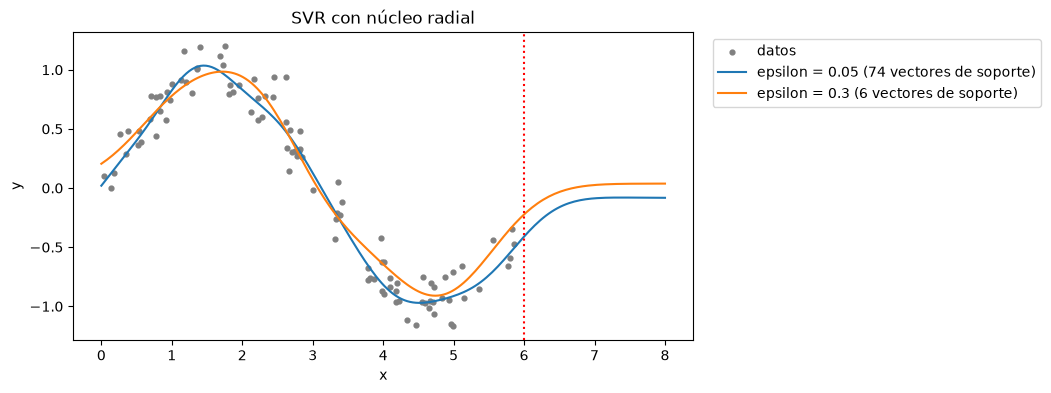

In [9]:
rng = np.random.default_rng(42)
x = np.sort(rng.uniform(0, 6, 100))
y_seno = np.sin(x) + rng.normal(0, 0.15, 100)
x_rejilla = np.linspace(0, 8, 200).reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(x, y_seno, s=12, color="gray", label="datos")
for epsilon in [0.05, 0.3]:
    svr = SVR(kernel="rbf", C=10, epsilon=epsilon, gamma=1).fit(x.reshape(-1, 1), y_seno)
    plt.plot(x_rejilla, svr.predict(x_rejilla), label=f"epsilon = {epsilon} ({len(svr.support_)} vectores de soporte)")
plt.axvline(6, color="red", linestyle=":")
plt.title("SVR con núcleo radial")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

Con $\varepsilon = 0{,}05$ el tubo es estrecho y casi tres cuartas partes de los puntos (74 de 100) son vectores de soporte; con $\varepsilon = 0{,}3$ el tubo es ancho, la curva es más suave y solo 6 puntos sostienen el modelo. Fuera del rango de datos (a la derecha de la línea roja), el núcleo radial **no extrapola**: la curva se aplana en un valor casi constante (≈ 0), lejos del seno real.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Clase | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `SVC` / `SVR` | `C` | Penalización de violar el margen (regularización inversa) | Escala logarítmica ($10^{-2}$ a $10^{3}$); a más $C$, más sobreajuste |
| | `kernel` | `"rbf"` (por defecto), `"linear"`, `"poly"`, `"sigmoid"` | RBF si no sabes; lineal con muchas variables y pocos datos; evita `"sigmoid"` |
| | `gamma` | Alcance del núcleo (RBF, poly, sigmoid); `"scale"` por defecto | Empieza por `"scale"` y busca alrededor en escala logarítmica |
| | `degree`, `coef0` | Grado y término independiente del polinómico | `degree` 2 o 3 |
| | `class_weight` | Peso por clase | `"balanced"` con clases desbalanceadas |
| | `probability` | Activa `predict_proba` con una validación cruzada interna | **Obsoleto desde 1.9**: usa `CalibratedClassifierCV(SVC(), ensemble=False)` |
| `SVR` | `epsilon` | Anchura del tubo sin penalización | Más ancho = modelo más simple y menos vectores de soporte |
| `LinearSVC` | `C`, `max_iter` | Igual que `C` en `SVC`; iteraciones | Para muchas filas; sube `max_iter` si avisa de que no converge |

### 4.2. Errores comunes

**1. No escalar.** En la sección 3.5, estandarizar sube la exactitud de test de 0,93 a 0,98. Mete siempre el escalador en un `Pipeline` para que se ajuste solo con el entrenamiento de cada partición.

**2. Rejilla de $C$ y $\gamma$ mal acotada.** Si el mejor valor sale en el **borde** de la rejilla (por ejemplo, $\gamma = 10$ con una rejilla que termina en 10), el óptimo puede estar más allá: amplía el rango hasta que el mejor punto quede en el interior, como en la sección 3.4. Y usa una escala logarítmica con saltos de un orden de magnitud, no una escala lineal.

**3. Interpretar un $C$ alto como "mejor modelo".** Un $C$ grande (por ejemplo, 50) significa que se castigan mucho las violaciones: **margen estrecho y menos regularización**, con más riesgo de sobreajuste, no más calidad por sí mismo. Y con $\gamma$ grande, la frontera dibuja islas alrededor de cada punto (sección 3.3). Mira siempre la brecha entre entrenamiento y validación, no solo el mejor valor de la rejilla.

**4. Confundir el sentido de $\gamma$.** $\gamma$ **pequeño** = cada punto influye en una zona amplia (frontera suave); $\gamma$ **grande** = influencia muy local (frontera ondulada, sobreajuste). Es fácil leerlo al revés porque en el núcleo $\gamma$ multiplica la distancia.

**5. Buscar hiperparámetros con todos los datos y una rejilla enorme.** Una rejilla de 35 combinaciones con 5 particiones son 175 entrenamientos, y el coste de cada uno crece más que linealmente con las filas (3.6). Para explorar, usa una **submuestra** o una búsqueda aleatoria (`RandomizedSearchCV`), y reentrena con todos los datos una vez elegidos los valores. Con muchas filas, cambia a `LinearSVC`.

**6. Esperar probabilidades de un `SVC` sin calibrar.** `SVC` solo da una puntuación (`decision_function`), no una probabilidad. `probability=True` calibraba con una validación cruzada interna (más tiempo), podía discrepar de `predict` y está obsoleto desde scikit-learn 1.9: usa `CalibratedClassifierCV(SVC(), ensemble=False)` (3.7). Si solo necesitas ordenar o umbralizar, `decision_function` basta.

**7. Ignorar el desbalanceo.** Con una clase rara, el margen se adapta a la mayoritaria. Usa `class_weight="balanced"`, [remuestrea](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb) y evalúa con métricas por clase, no con la exactitud.

**8. Usar el núcleo sigmoide sin comprobar.** Con algunos valores de sus parámetros no es un núcleo válido (no cumple la propiedad semidefinida positiva) y los resultados no tienen garantías. El radial cubre casi todos los casos.

**9. Esperar interpretabilidad.** Solo con núcleo lineal se puede leer `coef_`. Con núcleos no lineales, el modelo es una caja negra; si hay que explicar, un [árbol](08-arboles-decision.ipynb) o una regresión logística son más adecuados.

## 5. Comparación con métodos relacionados

| Método | Frontera | ¿Escalar? | Muchas filas | Muchas variables | Interpretabilidad | Probabilidades | Hiperparámetros clave |
|---|---|---|---|---|---|---|---|
| **SVM con núcleo (RBF)** | Curva, flexible | Imprescindible | Mal ($O(n^2)$–$O(n^3)$) | Bien | Baja | Calibradas aparte | `C`, `gamma` |
| **SVM lineal** (`LinearSVC`) | Hiperplano | Imprescindible | Bien | Muy bien | Alta (`coef_`) | No directas | `C` |
| Regresión logística | Hiperplano | Recomendable | Bien | Bien | Alta | Sí (nativas) | `C` (regularización) |
| [k-NN](07-knn.ipynb) | Local, flexible | Imprescindible | Predicción lenta | Mal | Por ejemplos | Aproximadas | `k`, distancia |
| [Árbol de decisión](08-arboles-decision.ipynb) | Rectangular | No | Bien | Aceptable | Alta (reglas) | Aproximadas | Profundidad, poda |
| [Random Forest](10-bagging-y-random-forest.ipynb) | Flexible | No | Bien | Bien | Media | Sí | Nº de árboles, profundidad |

**Cuándo elegir un SVM.** Con datos de **tamaño pequeño o mediano** (hasta unas decenas de miles de filas), con **muchas variables** relativas al número de filas (texto, genómica, imágenes pequeñas) y fronteras complejas, y cuando se puede dedicar tiempo a ajustar $C$ y $\gamma$. Un SVM lineal es una gran línea base para texto de alta dimensión.

**Cuándo no.** Con cientos de miles de filas (usa un modelo lineal o un bosque), cuando se necesitan probabilidades calibradas o explicaciones, o con muchos datos categóricos sin preprocesar.

## 6. Referencias

### Fuentes

- scikit-learn: [*Support Vector Machines*](https://scikit-learn.org/stable/modules/svm.html) (clasificación, regresión, complejidad, núcleos, probabilidades), [`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), [`LinearSVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html) y [`SVR`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html).
- scikit-learn: [`DecisionBoundaryDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html), [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) y [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).
- scikit-learn: datasets [`load_digits`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) y [`load_breast_cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html), y generadores [`make_blobs`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html), [`make_circles`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html), [`make_moons`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) y [`make_classification`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html).
- UCI Machine Learning Repository: [*Optical Recognition of Handwritten Digits*](https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits) y [*Breast Cancer Wisconsin (Diagnostic)*](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), origen de los conjuntos de datos.
- seaborn: [`heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html), usada para visualizar la rejilla.

### Para saber más

- Cortes, C. y Vapnik, V. (1995). *Support-vector networks*. Machine Learning, 20(3), 273–297. [doi:10.1007/BF00994018](https://doi.org/10.1007/BF00994018). El artículo que introduce el margen blando y consolida las SVM tal como se usan hoy.
- Hsu, C.-W., Chang, C.-C. y Lin, C.-J. (2003, actualizada en 2025). [*A Practical Guide to Support Vector Classification*](https://www.csie.ntu.edu.tw/~cjlin/papers/guide/guide.pdf). Informe técnico, National Taiwan University. Una receta práctica (escalar, núcleo RBF, rejilla logarítmica de $C$ y $\gamma$) de los autores de LIBSVM.